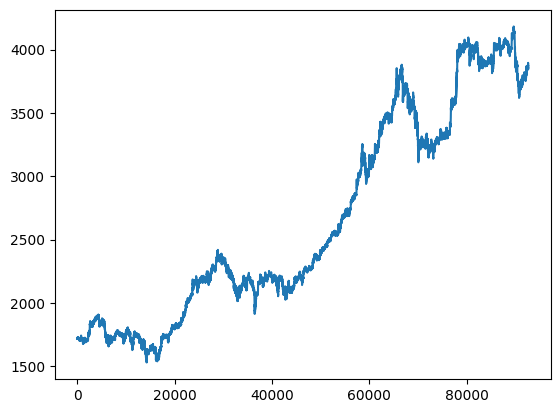

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

Data=pd.read_csv("ADANIENT_minute.csv")
data=Data.copy()
plt.plot(np.linspace(0,len(data),len(data)),data['close'])
plt.show()

In [60]:
data['logreturns']=np.log(data['close']/data['close'].shift(1))

data['cur']=data['close'].rolling(window=1000).mean()
data['long']=data['close'].rolling(window=50000).mean()

data['move']=np.where(data['cur']>data['long'],1,-1)
data['strat']=data['move'].shift(1)*data['logreturns']-0.0002*abs(data['move']-data['move'].shift(1))

data.dropna(inplace=True)

total_market_return=np.exp(data['logreturns'].sum())-1
total_strat_return=np.exp(data['strat'].sum())-1

sharpe_ratio=np.sqrt(252)*(data['strat'].mean()/data['strat'].std())

print(total_market_return)
print(total_strat_return)
print(sharpe_ratio)

0.4323982439169687
0.4319852264080337
0.1368299104039484


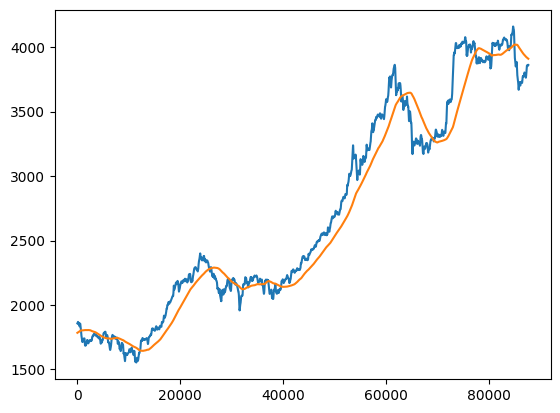

In [51]:
#print(data['cur'])
#print(data['long'])
plt.plot(np.linspace(0,len(data['cur']),len(data['cur'])),data['cur'])
plt.plot(np.linspace(0,len(data['cur']),len(data['cur'])),data['long'])
plt.show()

In [9]:
params=[5,100]
def ratio(w1,w2,Data):
    data=Data.copy()
    data['logreturns']=np.log(data['close']/data['close'].shift(1))
    data['cur']=data['close'].rolling(window=w1).mean()
    data['long']=data['close'].rolling(window=w2).mean()

    data['move']=np.where(data['cur']>data['long'],1,-1)
    data['strat']=data['move'].shift(1)*data['logreturns']

    data.dropna(inplace=True)
    if len(data) == 0:
            return 0
    sharpe_ratio=np.sqrt(252)*(data['strat'].mean()/data['strat'].std())
    return(sharpe_ratio)
def Ratio(w1,w2,Data):
    data=Data.copy()
    data['logreturns']=np.log(data['close']/data['close'].shift(1))
    data['cur']=data['close'].rolling(window=w1).mean()
    data['long']=data['close'].rolling(window=w2).mean()

    data['move']=np.where(data['cur']>data['long'],1,-1)
    data['strat']=data['move'].shift(1)*data['logreturns']

    data.dropna(inplace=True)
    if len(data) == 0:
            return 0
    market_return=np.exp(data['logreturns'].sum())-1
    strat_return=np.exp(data['strat'].sum())-1
    sharpe_ratio=np.sqrt(94500)*(data['strat'].mean()/data['strat'].std())
    print("Market returns at: "+str(market_return))
    print("Strategy return at : "+str(strat_return))
    print("Sharpe : "+str(sharpe_ratio))
def grad(params,data,rate):
    a=ratio(params[0],params[1],data)
    if(params[0]<=fastu and params[0]>=fastl):
        grad1=(ratio(params[0]+100,params[1],data)-a)
        try:
            #print(grad1)
            inc=int(grad1)
            if(grad1>0):
                if(grad1-inc>0.5):
                    params[0]+=inc+1
                else:
                    params[0]+=inc
            else:
                if(inc-grad1>0.5):
                    params[0]+=inc-1
                else:
                    params[0]+=inc
            if(params[0]>fastu):
                params[0]=fastu
            elif(params[0]<fastl):
                params[0]=fastl
        except ValueError:
            if(grad1>0):
                params[0]=fastu
            else:
                params[0]=fastl
    if(params[1]<=slowu and params[1]>=slowl):
        grad2=(ratio(params[0],params[1]+100,data)-a)
        try:
            #print(grad2)
            inc=int(rate*grad2)
            if(grad2>0):
                if(grad2-inc>0.5):
                    params[1]+=inc+1
                else:
                    params[1]+=inc
            else:
                if(inc-grad2>0.5):
                    params[1]+=inc-1
                else:
                    params[1]+=inc
            if(params[1]>slowu):
                params[1]=slowu
            elif(params[1]<slowl):
                params[1]=slowl
        except ValueError:
            if(grad2>0):
                params[1]=slowu
            else:
                params[1]=slowl
    return(a)
epochs=int(input())
costs=[]
maxparams=[0,0]
max=0

0


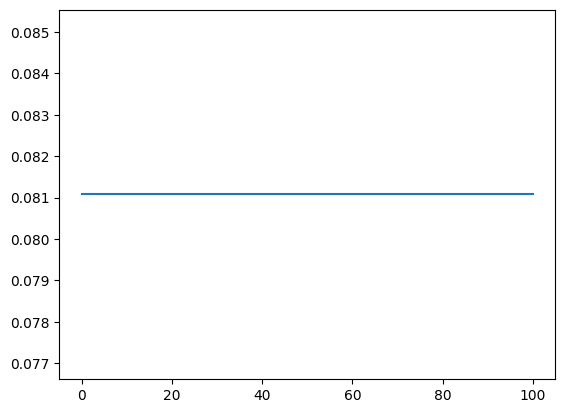

In [53]:
rate=10
for epoch in range(0,epochs):
    costs.append(grad(params,Data,rate))
    if(costs[-1]>=max):
        max=costs[-1]
        maxparams[0]=params[0]
        maxparams[1]=params[1]
    if(epoch%fastu==0):
        print(epoch)
plt.plot(np.linspace(0,len(costs),len(costs)),costs)

In [54]:
print(params)
print(maxparams)
print(max)
print(len(costs))
print(costs[-1])

[5, 100]
[5, 100]
0.08107505235786765
100
0.08107505235786765


In [55]:
data['logreturns']=np.log(data['close']/data['close'].shift(1))

data['cur']=data['close'].rolling(window=maxparams[0]).mean()
data['long']=data['close'].rolling(window=maxparams[1]).mean()

data['move']=np.where(data['cur']>data['long'],1,-1)
data['strat']=data['move'].shift(1)*data['logreturns']

data.dropna(inplace=True)

total_market_return=np.exp(data['logreturns'].sum())-1
total_strat_return=np.exp(data['strat'].sum())-1

sharpe_ratio=np.sqrt(252)*(data['strat'].mean()/data['strat'].std())

print(total_market_return)
print(total_strat_return)
print(sharpe_ratio)

1.0577231427044826
0.7563061452408923
0.08758919681184144


In [ ]:
fastl=1000
fastu=10000
slowl=10000
slowu=50000

In [15]:
data=pd.read_csv("ADANIENT_minute.csv")
Ratio(5,10000,data)

Market returns at: 1.1701755869338917
Strategy return at : 0.9778225137557834
Sharpe : 2.1896469189425662


In [16]:
data=pd.read_csv("AXISBANK_minute.csv")
Ratio(5,10000,data)

Market returns at: 0.16172724448589237
Strategy return at : 0.41202498603520255
Sharpe : 1.4172522953953004


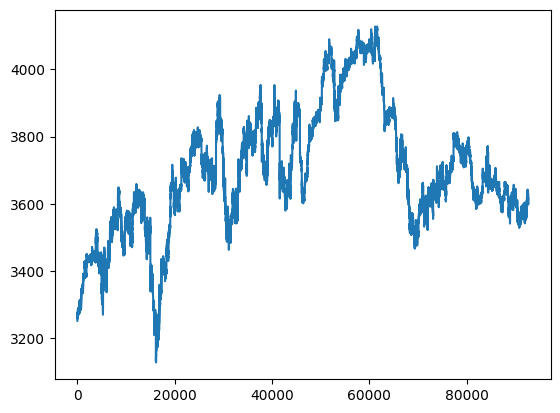

In [17]:
bajaj=pd.read_csv("BAJAJ-AUTO_minute.csv")
bajaj.columns=bajaj.columns.str.strip()
plt.plot(np.linspace(0,len(bajaj),len(bajaj)),bajaj['close'])
plt.show()

In [27]:
maxsharpe=0
window=0
for x in range(1000,50000,100):
    a=ratio(100,x,bajaj[0:(len(bajaj)//100)*80])
    if (x-1000)%1000==0:
        print(x)
    if(a>maxsharpe):
        maxsharpe=a
        window=x
print(window)
Ratio(100,window,bajaj[0:(len(bajaj)//100)*80])
Ratio(100,window,bajaj[(len(bajaj)//100)*80:len(bajaj)].reset_index(drop=True))

1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000
19000
20000
21000
22000
23000
24000
25000
26000
27000
28000
29000
30000
31000
32000
33000
34000
35000
36000
37000
38000
39000
40000
41000
42000
43000
44000
45000
46000
47000
48000
49000
46700
Market returns at: 0.004301814183617747
Strategy return at : 0.08558599289789592
Sharpe : 1.2710731854101545


0